In [1]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim


In [ ]:
model = nn.Sequential( #sequential fully connected
    nn.Linear(8, 12), #creates a layer that takes an input of size 8 and produces an output of size 12
    #each of the 8 input features is connected to each of the 12 output features
    #the out_features is the number of neurons of the defined layer 
    nn.ReLU(),
    nn.Linear(12, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)
print(model)

Sequential(
  (0): Linear(in_features=8, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


In [7]:
dataset = np.loadtxt('/home/leolr-int/nfs/ASTAR_internship/optimal_transport/pima-indians-diabetes.csv', delimiter=',')
X = dataset[:,0:8] #remember,  the slicing excludes the last numner, so here it is from 0 to 7 included
y = dataset[:,8]
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
#we need to convert the objects in a type suited for pytorch
loss_fn = nn.BCELoss() # binary cross-entropy because classification
optimizer = optim.Adam(model.parameters(), lr=0.001)
#Adam optimizer that will optimize the model's parameters with learning rate at 0.001
n_epochs = 100 #number of time the entire dataset will be passed through the neural network during training
batch_size = 10 #number of samples to be processed in each batch
for epoch in range(n_epochs):
    for i in range(0, len(X), batch_size): #do not forget to include the steps (batch)
        Xbatch = X[i:i+batch_size]
        y_pred = model(Xbatch) #prediction, forward pass
        ybatch = y[i:i+batch_size] #true values
        loss = loss_fn(y_pred, ybatch)
        optimizer.zero_grad() #clear the gradients of all optimized parameters to zero (necessary because by default gradients accumulate in PyTorch)
        loss.backward() #backward pass, computing the gradients of the loss with respect to the model weights
        optimizer.step() #updates the model parameters using the computed graidents and Adam
    print(f'Finished epoch {epoch}, latest loss {loss}')


Finished epoch 0, latest loss 0.5942273139953613
Finished epoch 1, latest loss 0.4655744135379791
Finished epoch 2, latest loss 0.44804441928863525
Finished epoch 3, latest loss 0.43577712774276733
Finished epoch 4, latest loss 0.43376976251602173
Finished epoch 5, latest loss 0.42731183767318726
Finished epoch 6, latest loss 0.43175792694091797
Finished epoch 7, latest loss 0.4177943170070648
Finished epoch 8, latest loss 0.42217037081718445
Finished epoch 9, latest loss 0.41990143060684204
Finished epoch 10, latest loss 0.41327381134033203
Finished epoch 11, latest loss 0.41144949197769165
Finished epoch 12, latest loss 0.41766929626464844
Finished epoch 13, latest loss 0.4082801938056946
Finished epoch 14, latest loss 0.41536590456962585
Finished epoch 15, latest loss 0.4093362092971802
Finished epoch 16, latest loss 0.427316814661026
Finished epoch 17, latest loss 0.4110356569290161
Finished epoch 18, latest loss 0.42573949694633484
Finished epoch 19, latest loss 0.4245683252811432

In [8]:
#To run an inference with the trained model, do this:
i = 5
X_sample = X[i:i+1]
model.eval() #tells python that the model will be run in inference mode
with torch.no_grad(): #crate a context for running the model without computing the gradient
    y_pred = model(X_sample)
print(f"{X_sample[0]} -> {y_pred[0]}")

tensor([  5.0000, 116.0000,  74.0000,   0.0000,   0.0000,  25.6000,   0.2010,
         30.0000]) -> tensor([0.1928])


In [9]:
model.eval()
with torch.no_grad():
    y_pred = model(X)
accuracy = (y_pred.round() == y).float().mean()
print(f"Accuracy: {accuracy}")

Accuracy: 0.7604166865348816


Torchvision is a sister library of pytroch specialised in computer vision. It also provides some datasets. 

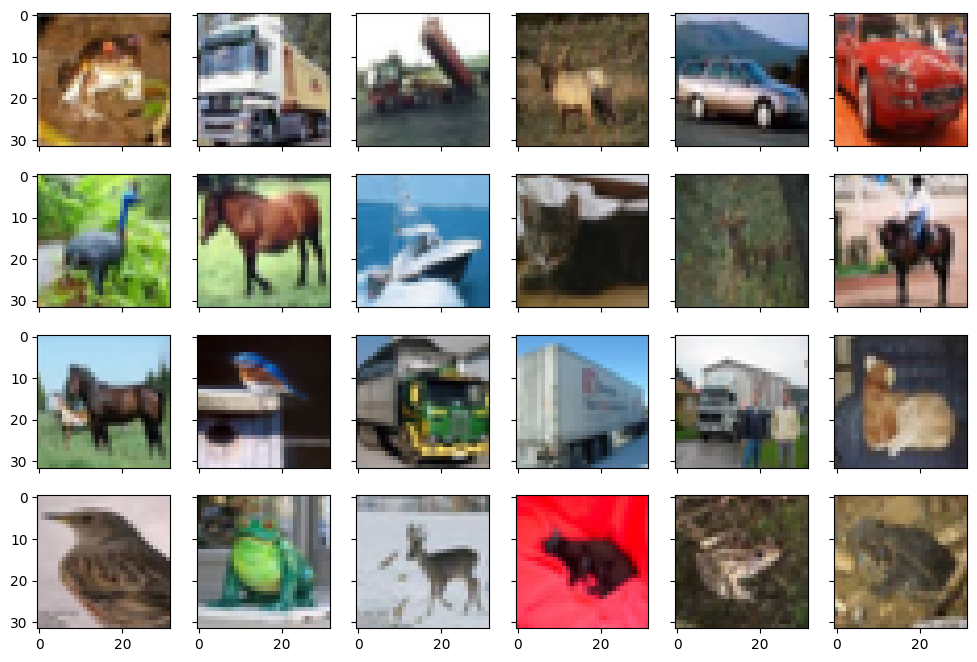

In [27]:
# dowloading a dataset

import matplotlib.pyplot as plt
import torchvision
transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])
 #the transform argument in the dataset extraction function below enables to direclty convert the data into PyTorch tensors

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
fig, ax = plt.subplots(4, 6, sharex=True, sharey=True, figsize=(12,8))
for i in range(0, 24):
    row, col = i//6, i%6
    ax[row][col].imshow(trainset.data[i])
plt.show()


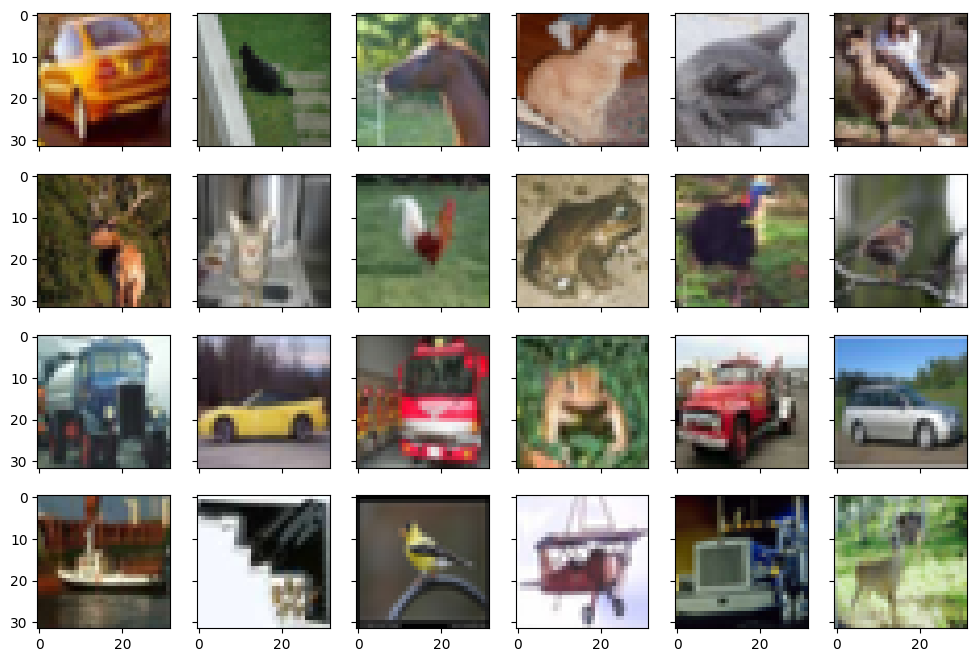

In [28]:
#DataLoader to transform the numpy dataset into PyTorch dataset
#very useful for datasets that are so large they cannot fit into the memory all at once
batch_size = 24
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=True)
#the Shuffle parameter enables to shuffle data at each epoch
#specifying the batch_size inside the DataLoader avoids writing explicitely a loop to handle batches during training (but a loop must still be written)

fig, ax = plt.subplots(4, 6, sharex=True, sharey=True, figsize=(12,8))
for images, labels in trainloader: #the dataloader is an iterable!
    for i in range(batch_size):
        row, col = i//6, i%6
        ax[row][col].imshow(images[i].numpy().transpose([1,2,0]))
    break # take only the first batch
plt.show()

Convolutional network

In [29]:
model = nn.Sequential(#fully connected feed forward
    nn.Conv2d(3, 32, kernel_size=(3,3), stride=1, padding=1),
    #Convolutional layer
    #3 color channels, 32*32 images, filter/kernel of size 3*3 (9 weights), stride = 1 --> the filter moves by one pixel (so, there is overlapping here)
    #because of the stride and the kernel size and the dimensions of the image, there will be 32 kernels in total (feature map)
    # these are stacked to form a tensor of depth 32
    nn.ReLU(),
    nn.Dropout(0.3),
    #30% of the outputs will be turned off (set to zero)
    #after a convolutional layer, it means that 30% of the outputs in the features map after non linearity will be dropped out
    # so here it means that 30% of the "pixels" (seen as output of neurons) of the newly formed "images" are dropped out
    nn.Conv2d(32, 32, kernel_size=(3,3), stride=1, padding=1),
    # the input has channel of length 32, and the image is still 32*32 (average of each cell of the filter)
    # each filter in the current layer needs to be applied to all the fature maps produced by the previous layer
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=(2, 2)),
    #reduce spatial dimensions by taking the max in each 2*2 window
    #this kernel divides the size of the input by 2 in the H*W space
    #the output is size 16*16*32 =  because the max pool is applied to each channel
    nn.Flatten(),
    nn.Linear(8192, 512),
    #be careful about the input dimensions
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 10)
)
print(model)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=8192, out_features=512, bias=True)
  (8): ReLU()
  (9): Dropout(p=0.5, inplace=False)
  (10): Linear(in_features=512, out_features=10, bias=True)
)


In [ ]:
#Training a convolutional network

import torch.optim as optim
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
#need a full course about Stochastic Gradient Descent

n_epochs = 20
for epoch in range(n_epochs):
    model.train() #tells python that the model will be used for training
    for inputs, labels in trainloader:
        y_pred = model(inputs)
        loss = loss_fn(y_pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    acc = 0
    count = 0
    model.eval() 
    with torch.no_grad():
        for inputs, labels in testloader:
            y_pred = model(inputs)
            acc += (torch.argmax(y_pred, 1) == labels).float().sum()
            #see explanations below
            count += len(labels)
    acc/=count
    print("Epoch %d: model accuracy %.2f%%" %(epoch, acc*100))

#Here, we trained the model *without* a GPU --> 17min12

Epoch 0: model accuracy 39.50%
Epoch 1: model accuracy 46.16%
Epoch 2: model accuracy 48.38%
Epoch 3: model accuracy 51.75%
Epoch 4: model accuracy 54.18%
Epoch 5: model accuracy 56.08%
Epoch 6: model accuracy 58.35%
Epoch 7: model accuracy 59.56%
Epoch 8: model accuracy 59.32%
Epoch 9: model accuracy 61.43%
Epoch 10: model accuracy 64.07%
Epoch 11: model accuracy 64.36%
Epoch 12: model accuracy 65.04%
Epoch 13: model accuracy 66.14%
Epoch 14: model accuracy 67.22%
Epoch 15: model accuracy 67.87%
Epoch 16: model accuracy 68.31%
Epoch 17: model accuracy 68.25%
Epoch 18: model accuracy 68.79%
Epoch 19: model accuracy 69.50%


acc += (torch.argmax(y_pred, 1) == labels).float().sum()


Here we are in a multiclass problem: for each input, the ANN will give a vector giving the scores of the input foe each label (like softmax probabilities). The predicted label is the one with the highest score (bounded by one). 

torch.argmax(,) takes as arguments the object and the dimension: it returns the index of the maximum along the dimension. Here, each row corresponds to a score and each column correponds to an element (we can vectorise operations!!) 

y_pred = model(inputs) --> several inputs are given because the are in batch, there are all stacked horizontally (olumn-wise) --> [y1, y2, ...]

In [ ]:
#train with GPU


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
#We send the model and the data to GPU before execution

#Then modify the code to send the data on the GPU too!! Use .to(device) for each data
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
#need a full course about Stochastic Gradient Descent

n_epochs = 20
for epoch in range(n_epochs):
    model.train() #tells python that the model will be used for training
    for inputs, labels in trainloader:
        y_pred = model(inputs.to(device))
        loss = loss_fn(y_pred, labels.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    acc = 0
    count = 0
    model.eval() 
    with torch.no_grad():
        for inputs, labels in testloader:
            y_pred = model(inputs.to(device))
            acc += (torch.argmax(y_pred, 1) == labels.to(device)).float().sum()
            #see explanations below
            count += len(labels) #here no need to send the data to the GPU
    acc/=count
    print("Epoch %d: model accuracy %.2f%%" %(epoch, acc*100))

#time taken with GPU: 2min12s (8.5 times faster)

Epoch 0: model accuracy 39.33%
Epoch 1: model accuracy 44.73%
Epoch 2: model accuracy 48.62%
Epoch 3: model accuracy 51.51%
Epoch 4: model accuracy 54.17%
Epoch 5: model accuracy 56.26%
Epoch 6: model accuracy 58.33%
Epoch 7: model accuracy 59.95%
Epoch 8: model accuracy 60.63%
Epoch 9: model accuracy 62.12%
Epoch 10: model accuracy 63.79%
Epoch 11: model accuracy 64.15%
Epoch 12: model accuracy 64.38%
Epoch 13: model accuracy 66.25%
Epoch 14: model accuracy 66.39%
Epoch 15: model accuracy 67.35%
Epoch 16: model accuracy 68.06%
Epoch 17: model accuracy 67.61%
Epoch 18: model accuracy 68.53%
Epoch 19: model accuracy 68.42%


## Other tests

We can customize architectures by defining new objects

In [ ]:
class SimpleNN(nn.Module): #it inherits the nn.Module class from PyTorch
    def __init__(self):
        super(SimpleNN, self).__init__() #this calls the construcctor of the parent class nn.Module
        self.layer1 = nn.Linear(16, 32)
        self.layer2 = nn.Linear(32, 1)
    
    def forward(self, x): #this will be used implicitely, output = model2(input)
        x = torch.relu(self.layer1(x))
        x = torch.sigmoid(self.layer2(x))
        return x

#model initialisation
model2 = SimpleNN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model2.parameters(), lr=0.01)
#...


## Understanding 'Network' 

In [ ]:
import os

import timm
import torch
import torch.nn as nn
from timm.layers import SwiGLUPacked
#timm stands for "Torch image models", we extract a Swish Gated linear Unit layer, 
# Packed suggests that this is optimized for or structured in a particular way
from timm.models.vision_transformer import VisionTransformer 

ENCODER_DIMS = {
    "uni":      1024,
    "gigapath": 1536,
    "virchow":  2560
}


class Network(nn.Module):

    """
    Initializes the network with a foundation model as the encoder
    and a linear layer as the classifier.

    Parameters
    ----------
    encoder_name: str
        The foundation model to be used as the encoder.
        One of [uni, gigapath, virchow].

    encoder_dir: str
        The directory containing the encoder weights.

    num_classes: int
        The number of classes to be classified.
    
    freeze_encoder: bool
        Whether to freeze the encoder during finetuning.
    """

    def __init__(
        self,
        encoder_name: str,
        encoder_dir: str,
        num_classes: int = 2,
        freeze_encoder: bool = True
        ):
        super().__init__() #constructor of a superclass of toch.nn

        self.encoder = get_encoder(encoder_name, encoder_dir)
        self.fc = get_classification_head(encoder_name, num_classes)
        #functions that are defined below
        self.freeze_encoder = freeze_encoder

        if self.freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False #the weights are one by one frozen

    def forward(self, x):
        if self.freeze_encoder:
            with torch.no_grad():
                embedding = self.encoder(x)

        else:
            embedding = self.encoder(x)
            
        logits = self.fc(embedding)

        return logits


class ClassificationHead(nn.Module):

    """
    Initializes a linear classification head.

    Parameters
    ----------
    in_dim: int
        The input dimension of the classifier.

    out_dim: int
        The output dimension of the classifier or 
        the number of classes.
    """

    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.head = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        logits = self.head(x)

        return logits
    

class VirchowConcat(nn.Module):
    
    """
    Performs the concatenation of the CLS token and mean across patch
    tokens as defined in Virchow.

    Source: https://arxiv.org/pdf/2309.07778

    Parameters
    ----------
    encoder: nn.Module
        The Virchow encoder. 
    """
    
    def __init__(
        self, 
        encoder: nn.Module
        ):
        super().__init__()
        self.encoder = encoder

    def forward(self, x):
        all_tokens = self.encoder(x)

        cls_token = all_tokens[:, 0]
        patch_tokens = all_tokens[:, 1:].mean(1)

        embedding = torch.cat([cls_token, patch_tokens], dim=-1)

        return embedding


def download_weights(
    encoder_name: str,
    encoder_dir: str
    ):

    """
    Downloads the weights of a foundation model to a selected directory.

    Parameters
    ----------
    encoder_name: str
        The foundation model to be used as the encoder.
        One of [uni, gigapath, virchow].

    encoder_dir: str
        The directory containing the encoder weights.
    """

    if encoder_name not in ENCODER_DIMS:
        raise ValueError(f"encoder must be one of {ENCODER_DIMS}")

    if encoder_name == "uni":
        encoder = timm.create_model("hf-hub:MahmoodLab/uni", pretrained=True, init_values=1e-5, dynamic_img_size=True)

    if encoder_name == "gigapath":
        encoder = timm.create_model("hf_hub:prov-gigapath/prov-gigapath", pretrained=True, dynamic_img_size=True)

    if encoder_name == "virchow":
        encoder = timm.create_model("hf-hub:paige-ai/Virchow", pretrained=True, mlp_layer=SwiGLUPacked, act_layer=torch.nn.SiLU)

    encoder_path = os.path.join(encoder_dir, f"{encoder_name}.pth")
    torch.save(encoder, encoder_path)


def get_encoder(
    encoder_name: str,
    encoder_dir: str
    ) -> VisionTransformer:

    """
    Returns an initialized foundation encoder.

    Parameters
    ----------
    encoder_name: str
        The foundation model to be used as the encoder.
        One of [uni, gigapath, virchow].

    encoder_dir: str
        The directory containing the encoder weights.

    Returns
    -------
    encoder: VisionTransformer
        The initialized foundation encoder.
    """

    if encoder_name not in ENCODER_DIMS:
        raise ValueError(f"encoder must be one of {list(ENCODER_DIMS.keys())}.")
    
    os.makedirs(encoder_dir, exist_ok=True)
    encoder_path = os.path.join(encoder_dir, f"{encoder_name}.pth")

    if not os.path.isfile(encoder_path):
        download_weights(encoder_name, encoder_dir=encoder_dir)

    encoder = torch.load(encoder_path, map_location=torch.device("cpu"), weights_only=False)
    #the model weights are stored in the CPU, good practice 
    # because allows easier debugging, avoid errors in case no GPU and its easy to me it to the GPU
    #weights_only: file being downloaded contains only tensor data (weights) or other Python objects?
    # turned to False if you store the architecture too
    
    if encoder_name == "virchow":
        encoder = VirchowConcat(encoder=encoder)

    return encoder

    
def get_classification_head(
    encoder_name: str,
    num_classes: int
    ) -> ClassificationHead:

    """
    Initializes the appropriate classification head
    according to a selected foundation encoder.

    Parameters
    ----------
    encoder_name: str
        The foundation model to be used as the encoder.
        One of [uni, gigapath, virchow].

    num_classes: int
        The number of output classes.
    """

    if encoder_name not in ENCODER_DIMS:
        raise ValueError(f"encoder must be one of {ENCODER_DIMS}")

    in_dims = ENCODER_DIMS[encoder_name]
    head = ClassificationHead(in_dim=in_dims, out_dim=num_classes)

    return head

## Understanding 'Network Handler'

In [ ]:
import os
from typing import (
    Tuple, 
    Literal
)
# specify that Tuple is a type, Literal provides an easy way to specify the values of some parameters
#def set_color(color: Literal["red", "green", "blue"]) -> None:
    #print(f"Color set to {color}")


import torch
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.amp import GradScaler
#Automatic mixed precision module, speed up training by combining single / half precision floating points formats.
#GradScaler helps manage numerical stability and precision issues arising with half-precision
from torch.utils.data import DataLoader
from deeplake import Dataset as DeepLakeDataset
from sklearn.metrics import balanced_accuracy_score

from .network import Network
from .save import save_table


class NetworkHandler:

    """
    This class encapsulates all computation logic for a given neural network,
    including training, validation, inference and embedding extraction.
    
    Supports mixed precision training.

    Parameters
    ----------
    model: Network
        The neural network.

    criterion: nn.Module
        The function for loss computation.

    optimizer: torch.optim.Optimizer
        The optimizer for gradient descent.

    precision: Literal['single', 'mixed']
        Whether to train in mixed or single precision.
        Must be one of ['single', 'mixed'].

    freeze_encoder: bool
        Whether the encoder is frozen.
        Will be used as a flag in switching between train and eval modes.

    embedding_mode: bool
        Whether to perform computations on pre-extracted embeddings.
    """

    def __init__(
        self,
        model: Network,
        criterion: nn.Module = None,
        optimizer: torch.optim.Optimizer = None, 
        precision: Literal["single", "mixed"] = "single",
        freeze_encoder: bool = True,
        embedding_mode: bool = False
        ):

        valid_precisions = ["single", "mixed"]

        if precision not in valid_precisions:
            raise ValueError(f"precision must be one of  {valid_precisions}.")

        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.freeze_encoder = freeze_encoder
        
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.use_amp = precision == "mixed" and self.device == "cuda"
        self.grad_scaler = GradScaler(enabled=self.use_amp)
        self.model = self.model.to(self.device)
        self.embedding_mode = embedding_mode

        if self.device != "cuda" and precision == "mixed":
            raise ValueError(f"Mixed precision unavailable with current device: {self.device}. Switch to single precision.\n")


    def train_epoch(self, train_loader: DataLoader) -> Tuple[float, float]:

        """
        Trains the model for 1 epoch.

        Parameters
        ----------
        train_loader: DataLoader
            The data loader for training.

        Returns
        -------
        epoch_loss: float
            The loss for the epoch.

        epoch_balanced_accuracy: float
            The average balanced accuracy for the given epoch.  
        """
        
        metrics = {
            "running_loss": 0,
            "predictions": [],
            "targets": []
        }
        
        self.model.train()
        if self.freeze_encoder or self.embedding_mode: self.model.encoder.eval()

        pbar = tqdm(train_loader, desc="Training in progress")

        for patch, target, *_ in pbar: #*_ is used to ignore all other values from the iterable
            patch = patch.to(self.device)
            target =  target.to(self.device)

            #autocast is used for automatic mixed precision
            with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                logits = self.model.fc(patch) if self.embedding_mode else self.model(patch) 
                #here enables to used pre-computed embeddings or compute them direclty
                loss = self.criterion(logits, target)
            #backpropagation with mixed precision handling
            self.grad_scaler.scale(loss).backward()
            self.grad_scaler.step(self.optimizer)
            self.grad_scaler.update()
            #adjusts the scale factor for next iteration
            self.optimizer.zero_grad()
            #dont forget to reset the gradient after each batch

            confidence = F.softmax(logits, dim=1)
            #logits are in R
            pred = torch.argmax(confidence, dim=1)
            #i could recover entropy easily

            metrics["running_loss"] += loss.detach().cpu().item()
            #item is to recover the scalar value, detach is to detach from the computational graph
            # to avoid that a gradient is computed over this value because it comes from the loss!
            metrics["predictions"].extend(pred.cpu().numpy())
            #extend enables to add many elements to a list
            metrics["targets"].extend(target.cpu().numpy())

            pbar.set_postfix({"step_loss": loss.detach().cpu().item()})
            #dynamically update the progress bar with current batchs loss value

        epoch_loss = metrics["running_loss"] / len(train_loader)
        epoch_balanced_accuracy = balanced_accuracy_score(metrics["targets"], metrics["predictions"])

        return epoch_loss, epoch_balanced_accuracy
    

    @torch.no_grad()
    #function signature COMPULSORY for evaluation: disables gradient computation
    def validate_epoch(self, val_loader: DataLoader) -> Tuple[float, float]:

        """
        Runs validation for 1 epoch.

        Parameters
        ----------
        val_loader: DataLoader
            The data loader for validation.

        Returns
        -------
        epoch_loss: float
            The loss for the epoch.

        epoch_balanced_accuracy: float
            The average balanced accuracy for the given epoch.  
        """

        metrics = {
            "running_loss": 0,
            "predictions": [],
            "targets": []
        }

        self.model.eval()
        pbar = tqdm(val_loader, desc="Validation in progress")
        for patch, target, *_ in pbar:
            patch = patch.to(self.device)
            target = target.to(self.device)

            with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                logits = self.model.fc(patch) if self.embedding_mode else self.model(patch)
                loss = self.criterion(logits, target)

            confidence = F.softmax(logits, dim=1)
            pred = torch.argmax(confidence, dim=1)

            metrics["running_loss"] += loss.detach().cpu().item()
            metrics["predictions"].extend(pred.cpu().numpy())
            metrics["targets"].extend(target.cpu().numpy())

            pbar.set_postfix({"step_loss": loss.detach().cpu().item()})

        epoch_loss = metrics["running_loss"] / len(val_loader)
        epoch_balanced_accuracy = balanced_accuracy_score(metrics["targets"], metrics["predictions"])

        return epoch_loss, epoch_balanced_accuracy
    
    @torch.no_grad()
    def inference(
        self, 
        inference_loader: DataLoader, 
        save_dir: str = None,
        filename: str = None
        ) -> Tuple[float, float]:

        """
        Performs inference and optionally saves the results as a parquet table
        for downstream analysis.

        Parameters
        ----------
        inference_loader: DataLoader
            The data loader for inference.

        save_dir: str
            The directory to save results.

        filename: str
            The filename to save the results into.

        Returns
        -------
        iteration_loss: float
            The average loss during inference.

        iteration_balanced_accuracy:
            The average balanced accuracy during inference.
        """

        if save_dir and not filename:
            raise ValueError("filename cannot be empty if save dir is specified.")
        
        if filename and not save_dir:
            raise ValueError(f"save_dir must be provided to save results as {filename}")

        metrics = {
            "loss": [],
            "confidence_score": [],
            "prediction": [],
            "target": [],
            "area": [],
            "x": [],
            "y": [],
            "w": [],
            "h": [],
            "img_idx": []
        }

        self.model.eval()
        pbar = tqdm(inference_loader, desc="Inference in progress")
        for patch, target, metadata in pbar:
            patch = patch.to(self.device)
            target = target.to(self.device)

            with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                logits = self.model.fc(patch) if self.embedding_mode else self.model(patch)
                loss = self.criterion(logits, target)

            confidence = F.softmax(logits, dim=1)
            pred = torch.argmax(confidence, dim=1)

            metrics["loss"].extend(loss.detach().cpu().numpy())
            metrics["confidence_score"].extend(confidence.cpu().numpy())
            metrics["prediction"].extend(pred.cpu().numpy())
            metrics["target"].extend(target.cpu().numpy())
            
            metrics["area"].extend(metadata["area"].cpu().numpy())
            metrics["x"].extend(metadata["x"].cpu().numpy())
            metrics["y"].extend(metadata["y"].cpu().numpy())
            metrics["w"].extend(metadata["w"].cpu().numpy())
            metrics["h"].extend(metadata["h"].cpu().numpy())
            metrics["img_idx"].extend(metadata["img_idx"].cpu().numpy())

        iteration_loss = sum(metrics["loss"]) / len(metrics["loss"])
        iteration_balanced_accuracy = balanced_accuracy_score(metrics["target"], metrics["prediction"])

        if save_dir and filename:
            save_table(metrics, save_dir, filename)

        return iteration_loss, iteration_balanced_accuracy
    
    @torch.no_grad()
    def predict(
        self,
        pred_loader: DataLoader,
        save_dir: str = None,
        filename: str = None
        ):
    
        """
        This method is used when the dataset contains samples with no labels.
        Outputs predictions for each patch without performing evaluation.

        Optionally, will save results as a parquet table for downstream analysis.

        Parameters
        ----------
        pred_loader: DataLoader
            The data loader to iterate over.
        
        save_dir: str
            The directory to save results.

        filename: str
            The filename to save the results into.
        """

        if save_dir and not filename:
            raise ValueError("filename cannot be empty if save dir is specified.")
        
        if filename and not save_dir:
            raise ValueError(f"save_dir must be provided to save results as {filename}")
        
        metrics = {
            "confidence_score": [],
            "prediction": [],
            "target": [],
            "area": [],
            "x": [],
            "y": [],
            "w": [],
            "h": []
        }

        self.model.eval()
        pbar = tqdm(pred_loader, desc="Prediction in progress")
        for patch, target, metadata in pbar:
            patch = patch.to(self.device)
            target = target.to(self.device)

            with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                logits = self.model.fc(patch) if self.embedding_mode else self.model(patch)
            
            confidence = F.softmax(logits, dim=1)
            pred = torch.argmax(confidence, dim=1)

            metrics["confidence_score"].extend(confidence.cpu().numpy())
            metrics["prediction"].extend(pred.cpu().numpy())
            metrics["target"].extend(target.cpu().numpy())
            
            metrics["area"].extend(metadata["area"].cpu().numpy())
            metrics["x"].extend(metadata["x"].cpu().numpy())
            metrics["y"].extend(metadata["y"].cpu().numpy())
            metrics["w"].extend(metadata["w"].cpu().numpy())
            metrics["h"].extend(metadata["h"].cpu().numpy())

        if save_dir and filename:
            save_table(metrics, save_dir, filename)

    @torch.no_grad()
    def extract_embeddings(
        self, 
        embed_loader: DataLoader,
        deeplake_ds: DeepLakeDataset,
        img_idx: int
        ):

        """
        Extracts and saves embeddings in a deep lake dataset.

        Assumes the existence of three inputs:
            - image patch
            - label
            - file key (an index that maps to a file to trace each embedding back to the original image)

        Parameters
        ----------
        embed_loader: DataLoader
            The data loader to iterate throught the dataset.

        deeplake_ds: DeepLakeDataset
            The deeplake dataset to store the embeddings.

        img_idx: int
            The index id of the slide associated with the patch.
        """

        self.model.eval()
        pbar = tqdm(embed_loader, desc="Extracting embeddings")
        for patch, label, metadata in pbar:
            patch = patch.to(self.device)

            with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                embedding = self.model.encoder(patch)

            embedding = embedding.detach().cpu()

            area = metadata["area"]
            x = metadata["x"]
            y = metadata["y"]
            w = metadata["w"]
            h = metadata["h"]
            img_idx_batched = np.broadcast_to(img_idx, x.shape)

            deeplake_ds.append({
                "embedding": embedding.numpy(),
                "label": label.numpy(),
                "area": area.numpy(),
                "x": x.numpy(),
                "y": y.numpy(),
                "w": w.numpy(),
                "h": h.numpy(),
                "img_idx": img_idx_batched
            })

def save_checkpoint(
    save_dir: str,
    model: nn.Module, 
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler,
    scaler: torch.amp.GradScaler,
    epoch: int,
    balanced_accuracy: torch.Tensor | float,
    loss: torch.Tensor | float,
    min_val_loss: torch.Tensor | float,
    max_val_accuracy: torch.Tensor | float
    ):

    training_state = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch,
        "balanced_accuracy": balanced_accuracy,
        "loss": loss,
        "min_val_loss": min_val_loss,
        "max_val_accuracy": max_val_accuracy
    }

    torch.save(training_state, os.path.join(save_dir, "checkpoint.pth"))
